# SHARC trajectory analyser

## 1. Setup


In [201]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run from the repository root or sharc/. Change this for another SHARC run.
SEARCH_ROOT = Path("sharc") if Path("sharc").is_dir() else Path(".")
RUN_DIRECTORY = "ethene_molcas"
TRAJECTORY_CUTOFF_TIME_FS = 200.0

# shnitsel.sanity_check defaults: Å for lengths and eV for energies.
ANY_BOND_MAX = 3.01
CH_NH_BOND_MAX = 2.0
ACTIVE_POTENTIAL_STEP_MAX = 0.7
HOP_POTENTIAL_STEP_MAX = 1.0
TOTAL_ENERGY_STEP_MAX = 0.1
TOTAL_ENERGY_DRIFT_MAX = 0.2
KINETIC_ENERGY_STEP_MAX = 0.7
TIME_ATOL_FS = 1e-6
RADII = {"H": .31, "B": .85, "C": .76, "N": .71, "O": .66, "F": .57,
         "P": 1.07, "S": 1.05, "Cl": 1.02, "Br": 1.20, "I": 1.39}
BOND_RADIUS_SCALE = 1.25
ETHENE_SYMBOLS = ["C", "C", "H", "H", "H", "H"]
ETHENE_BONDS = ((0, 1), (0, 2), (0, 5), (1, 3), (1, 4))  # C-C, then C-H
CRITERIA = ("any_bond_length", "ch_nh_bond_length", "active_potential_step",
            "hop_potential_step", "total_energy_step", "total_energy_drift",
            "kinetic_energy_step", "unreadable_sharc_output")

def discover_trajectories():
    run_path = SEARCH_ROOT / RUN_DIRECTORY
    if not run_path.is_dir(): raise FileNotFoundError(f"Run directory not found: {run_path.resolve()}")
    found = sorted(path for path in run_path.rglob("TRAJ_*") if path.is_dir())
    if not found: raise FileNotFoundError(f"No TRAJ_* directories under {run_path.resolve()}")
    return found

def load_trajectory(directory):
    symbols, times, coordinates = parse_xyz(directory / "output.xyz")
    _, lis_times, states, kinetic, potential, total = parse_lis(directory / "output.lis")
    load_trajectory.truncated = parse_xyz.truncated or parse_lis.truncated
    common = min(len(times), len(states))
    if common == 0 or not np.allclose(times[:common], lis_times[:common], rtol=0, atol=TIME_ATOL_FS): raise ValueError("XYZ/LIS frames or times do not match")
    if len(times) != len(states): load_trajectory.truncated = True
    times, coordinates, states, kinetic, potential = times[:common], coordinates[:common], states[:common], kinetic[:common], potential[:common]
    return symbols, times, coordinates, states, kinetic, potential

def parse_xyz(path):
    """Read symbols, times (fs), and coordinates from SHARC output.xyz."""
    lines, pos, symbols, times, xyz = path.read_text().splitlines(), 0, None, [], []
    parse_xyz.truncated = False
    while pos < len(lines):
        while pos < len(lines) and not lines[pos].strip(): pos += 1
        if pos == len(lines): break
        try: natoms = int(lines[pos])
        except ValueError as exc: raise ValueError(f"expected atom count at line {pos + 1}") from exc
        if natoms <= 0 or pos + natoms + 1 >= len(lines): raise ValueError(f"incomplete XYZ frame at line {pos + 1}")
        time = re.search(r"\bt=\s*([-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?)", lines[pos + 1])
        if not time: raise ValueError(f"missing SHARC time in XYZ frame {len(times)}")
        if float(time.group(1)) > TRAJECTORY_CUTOFF_TIME_FS: break
        rows = [line.split() for line in lines[pos + 2:pos + 2 + natoms]]
        if any(len(row) < 4 for row in rows): raise ValueError(f"malformed atom record in XYZ frame {len(times)}")
        frame_symbols = [row[0] for row in rows]
        try: frame_xyz = [[float(value) for value in row[1:4]] for row in rows]
        except ValueError: parse_xyz.truncated = True; break
        if symbols is None: symbols = frame_symbols
        elif frame_symbols != symbols: raise ValueError(f"atom symbols/order change at XYZ frame {len(times)}")
        times.append(float(time.group(1))); xyz.append(frame_xyz); pos += natoms + 2
    if not xyz: raise ValueError("no XYZ frames")
    return symbols, np.asarray(times), np.asarray(xyz, dtype=float)

def parse_lis(path):
    """Read step, time, MCH state, Ekin, Epot(active), Etot from output.lis."""
    rows, parsed = [], []
    parse_lis.truncated = False
    for line in path.read_text().splitlines():
        if not line.strip() or line.lstrip().startswith("#"): continue
        row = line.split()
        if float(row[1]) > TRAJECTORY_CUTOFF_TIME_FS: break
        try: parsed.append([float(row[i]) for i in (0, 1, 3, 4, 5, 6)])
        except (ValueError, IndexError): parse_lis.truncated = True; break
    if not parsed: raise ValueError("no valid output.lis data rows")
    data = np.asarray(parsed)
    return data[:, 0].astype(int), data[:, 1], data[:, 2].astype(int), data[:, 3], data[:, 4], data[:, 5]

def infer_bonds(symbols, xyz0):
    """Infer zero-based covalent bonds from the initial geometry."""
    unknown = sorted(set(symbols) - set(RADII))
    if unknown: raise ValueError(f"no covalent radius configured for: {', '.join(unknown)}")
    bonds = [(i, j) for i in range(len(symbols) - 1) for j in range(i + 1, len(symbols))
             if np.linalg.norm(xyz0[i] - xyz0[j]) <= BOND_RADIUS_SCALE * (RADII[symbols[i]] + RADII[symbols[j]])]
    if not bonds: raise ValueError("could not infer any bonds from the initial geometry")
    return bonds

def sanity_masks(symbols, xyz, states, kinetic, potential):
    """Per-frame violations using shnitsel's default threshold semantics."""
    n = len(xyz)
    if not (len(states) == len(kinetic) == len(potential) == n): raise ValueError("coordinate and energy arrays have different frame counts")
    bonds = ETHENE_BONDS if symbols == ETHENE_SYMBOLS else infer_bonds(symbols, xyz[0])
    lengths = {(i, j): np.linalg.norm(xyz[:, i] - xyz[:, j], axis=1) for i, j in bonds}
    any_bond = np.any([value > ANY_BOND_MAX for value in lengths.values()], axis=0)
    hn_bonds = [(i, j) for i, j in bonds if {symbols[i], symbols[j]} in ({"C", "H"}, {"N", "H"})]
    ch_nh = np.any([lengths[pair] > CH_NH_BOND_MAX for pair in hn_bonds], axis=0) if hn_bonds else np.zeros(n, dtype=bool)
    hop = np.r_[False, states[1:] != states[:-1]]
    pot_step, kin_step = np.abs(np.diff(potential, prepend=potential[0])), np.abs(np.diff(kinetic, prepend=kinetic[0]))
    total = potential + kinetic
    return {
        "any_bond_length": any_bond,
        "ch_nh_bond_length": ch_nh,
        "active_potential_step": (~hop) & (pot_step > ACTIVE_POTENTIAL_STEP_MAX),
        "hop_potential_step": hop & (pot_step > HOP_POTENTIAL_STEP_MAX),
        "total_energy_step": np.abs(np.diff(total, prepend=total[0])) > TOTAL_ENERGY_STEP_MAX,
        "total_energy_drift": np.abs(total - total[0]) > TOTAL_ENERGY_DRIFT_MAX,
        "kinetic_energy_step": (~hop) & (kin_step > KINETIC_ENERGY_STEP_MAX),
    }

def initial_ethene_coordinates(symbols, xyz0):
    """Return the first C--C bond and H--C--C--H torsion, when present.

    For ethene this selects H(3)-C(1)-C(2)-H(4), using the lowest-index
    hydrogen attached to each carbon. Indices are inferred, not hard-coded.
    """
    bonds = ETHENE_BONDS if symbols == ETHENE_SYMBOLS else infer_bonds(symbols, xyz0)
    carbons = [i for i, symbol in enumerate(symbols) if symbol == "C"]
    if len(carbons) < 2:
        return np.nan, np.nan, "fewer than two carbon atoms"
    carbon_a, carbon_b = min(((i, j) for i in carbons for j in carbons if i < j),
                             key=lambda pair: np.linalg.norm(xyz0[pair[0]] - xyz0[pair[1]]))
    hydrogen_a = sorted(i if j == carbon_a else j for i, j in bonds
                        if carbon_a in (i, j) and symbols[i if j == carbon_a else j] == "H")
    hydrogen_b = sorted(i if j == carbon_b else j for i, j in bonds
                        if carbon_b in (i, j) and symbols[i if j == carbon_b else j] == "H")
    if not hydrogen_a or not hydrogen_b:
        return float(np.linalg.norm(xyz0[carbon_a] - xyz0[carbon_b])), np.nan, "missing H substituent for H-C-C-H torsion"
    p0, p1, p2, p3 = xyz0[[hydrogen_a[0], carbon_a, carbon_b, hydrogen_b[0]]]
    b0, b1, b2 = -(p1 - p0), p2 - p1, p3 - p2
    b1 /= np.linalg.norm(b1)
    v, w = b0 - np.dot(b0, b1) * b1, b2 - np.dot(b2, b1) * b1
    if np.linalg.norm(v) == 0 or np.linalg.norm(w) == 0:
        return float(np.linalg.norm(p1 - p2)), np.nan, "undefined H-C-C-H torsion"
    dihedral = np.degrees(np.arctan2(np.dot(np.cross(b1, v), w), np.dot(v, w)))
    return float(np.linalg.norm(p1 - p2)), float(abs((dihedral + 180) % 360 - 180)), None

def signed_dihedral_deg(coordinates, atom_indices=(3, 1, 2, 4)):
    """Return the signed 1-based H-C-C-H dihedral in degrees."""
    p0, p1, p2, p3 = coordinates[np.asarray(atom_indices, dtype=int) - 1]
    b0, b1, b2 = -(p1 - p0), p2 - p1, p3 - p2
    b1 /= np.linalg.norm(b1)
    v, w = b0 - np.dot(b0, b1) * b1, b2 - np.dot(b2, b1) * b1
    if np.linalg.norm(v) == 0 or np.linalg.norm(w) == 0:
        raise ValueError("undefined H-C-C-H dihedral")
    return float((np.degrees(np.arctan2(np.dot(np.cross(b1, v), w), np.dot(v, w))) + 180.0) % 360.0 - 180.0)

def validate_trajectory(directory):
    """Return one report record; unreadable input is not a physical failure."""
    xyz_path, lis_path = directory / "output.xyz", directory / "output.lis"
    row = {"trajectory": directory.name, "path": str(directory), "status": "invalid_input",
           "n_frames": pd.NA, "initial_cc_bond_angstrom": np.nan, "initial_hcch_dihedral_deg": np.nan, "initial_coordinate_reason": None, "first_violation_frame": pd.NA,
           "first_violation_time_fs": np.nan, "first_violation_criteria": None, "unreadable_sharc_output": False, "reason": None}
    for criterion in CRITERIA: row[f"{criterion}_first_frame"], row[f"{criterion}_first_time_fs"] = pd.NA, np.nan
    try:
        if not xyz_path.is_file() or xyz_path.stat().st_size == 0: raise ValueError("missing or empty output.xyz")
        if not lis_path.is_file() or lis_path.stat().st_size == 0: raise ValueError("missing or empty output.lis")
        symbols, xyz_times, xyz = parse_xyz(xyz_path)
        steps, lis_times, states, kinetic, potential, listed_total = parse_lis(lis_path)
        output_truncated = parse_xyz.truncated or parse_lis.truncated
        common = min(len(xyz_times), len(lis_times))
        if common == 0: raise ValueError("no aligned numeric XYZ/LIS frames")
        same_time = np.isclose(xyz_times[:common], lis_times[:common], rtol=0, atol=TIME_ATOL_FS)
        if not same_time.all():
            i = int(np.flatnonzero(~same_time)[0]); raise ValueError(f"XYZ/LIS time mismatch at frame {i}: {xyz_times[i]} != {lis_times[i]} fs")
        if len(xyz_times) != len(lis_times): output_truncated = True
        row["unreadable_sharc_output"] = bool(output_truncated)
        if output_truncated:
            row["unreadable_sharc_output_first_frame"] = common
            row["unreadable_sharc_output_first_time_fs"] = np.nan
        xyz_times, xyz = xyz_times[:common], xyz[:common]
        states, kinetic, potential, listed_total = states[:common], kinetic[:common], potential[:common], listed_total[:common]
        if not np.allclose(potential + kinetic, listed_total, rtol=0, atol=1e-5): raise ValueError("output.lis total energy does not equal Ekin + Epot")
        row["initial_cc_bond_angstrom"], row["initial_hcch_dihedral_deg"], row["initial_coordinate_reason"] = initial_ethene_coordinates(symbols, xyz[0])
        masks = sanity_masks(symbols, xyz, states, kinetic, potential); row["n_frames"] = len(xyz_times)
        bad = np.zeros(len(xyz_times), dtype=bool)
        for criterion, mask in masks.items():
            indices = np.flatnonzero(mask)
            if len(indices):
                i = int(indices[0]); row[f"{criterion}_first_frame"], row[f"{criterion}_first_time_fs"] = i, float(xyz_times[i]); bad |= mask
        if bad.any():
            i = int(np.flatnonzero(bad)[0])
            row.update(status="filtered", first_violation_frame=i, first_violation_time_fs=float(xyz_times[i]),
                       first_violation_criteria=", ".join(key for key, mask in masks.items() if mask[i]))
        elif output_truncated:
            row.update(status="filtered", first_violation_frame=len(xyz_times), first_violation_time_fs=np.nan, first_violation_criteria="unreadable SHARC output", unreadable_sharc_output=True)
        else: row["status"] = "valid"
    except (OSError, UnicodeDecodeError, ValueError) as exc: row["reason"] = str(exc)
    return row

def load_retained_trajectory(directory):
    """Load valid data, truncating a filtered trajectory before its failed frame."""
    report = validate_trajectory(directory)
    if report["status"] == "invalid_input":
        return None
    symbols, time_fs, xyz, states, kinetic, potential = load_trajectory(directory)
    stop = int(report["first_violation_frame"]) if report["status"] == "filtered" else len(time_fs)
    if stop == 0:
        return None
    return symbols, time_fs[:stop], xyz[:stop], states[:stop], kinetic[:stop], potential[:stop], report["status"]


## 2. Trajectory plotter


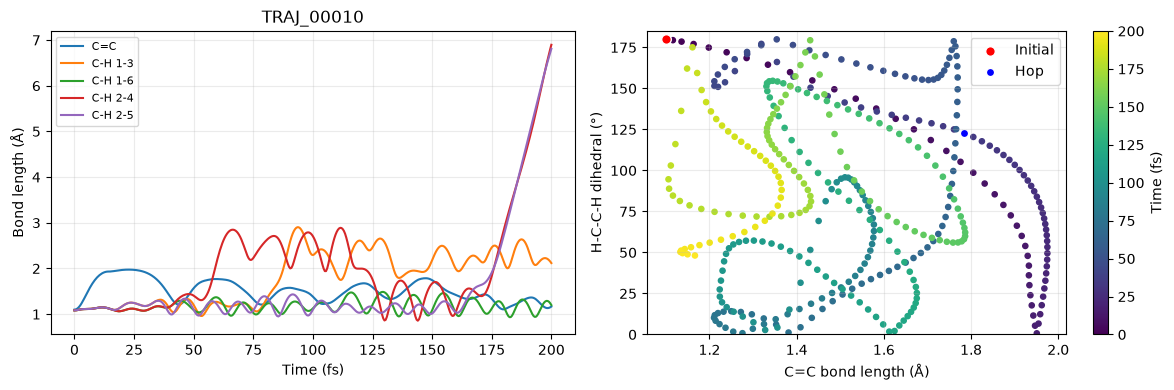

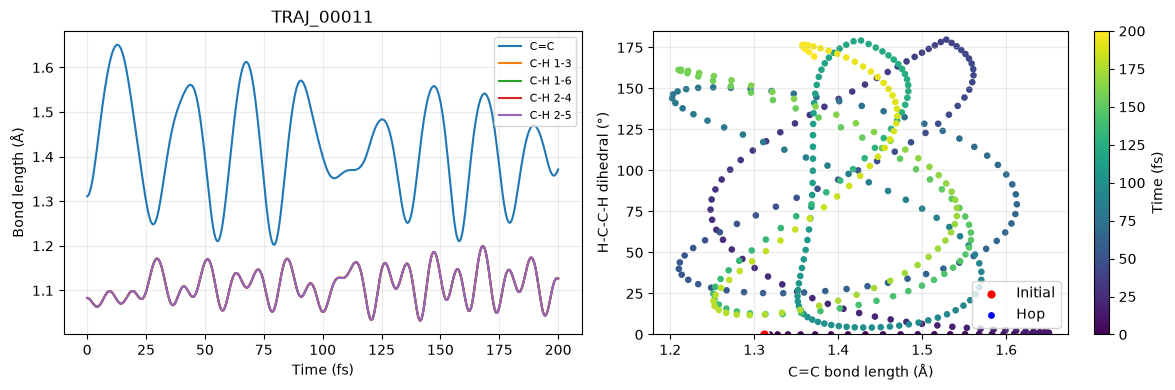

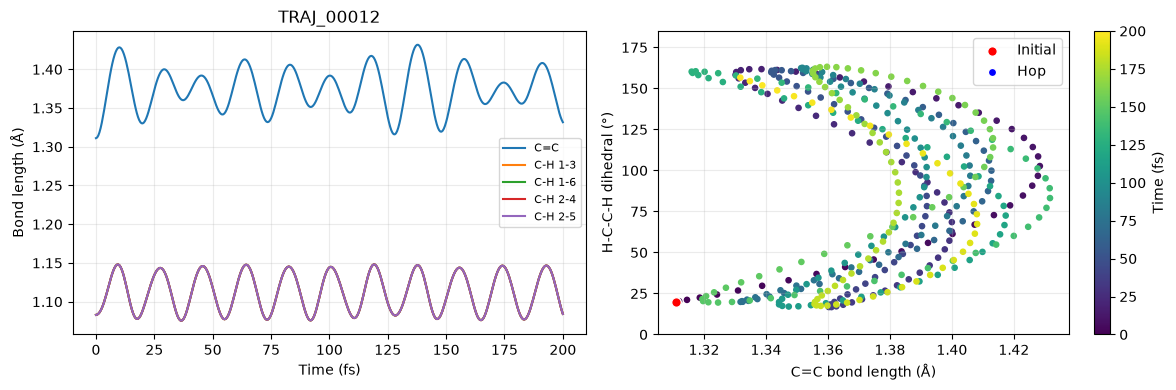

In [202]:
# Accept an integer, range, or sequence of trajectory numbers.
TRAJECTORIES_TO_PLOT = range(10,13)  
requested = {TRAJECTORIES_TO_PLOT} if isinstance(TRAJECTORIES_TO_PLOT, int) else set(TRAJECTORIES_TO_PLOT)
for directory in discover_trajectories():
    number = int(directory.name.removeprefix("TRAJ_"))
    if number not in requested: continue
    try:
        _, time, xyz, states, _, _ = load_trajectory(directory)
        cc = np.linalg.norm(xyz[:, 0] - xyz[:, 1], axis=1)
        ch = [np.linalg.norm(xyz[:, i] - xyz[:, j], axis=1) for i, j in ETHENE_BONDS[1:]]
        dih = np.asarray([abs(signed_dihedral_deg(frame)) for frame in xyz])
        hops = np.r_[False, states[1:] != states[:-1]]
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(time, cc, label="C=C")
        for pair, values in zip(ETHENE_BONDS[1:], ch): axes[0].plot(time, values, label=f"C-H {pair[0]+1}-{pair[1]+1}")
        axes[0].set(xlabel="Time (fs)", ylabel="Bond length (Å)", title=directory.name); axes[0].legend(fontsize=8); axes[0].grid(alpha=.25)
        points = axes[1].scatter(cc, dih, c=time, cmap="viridis", s=14)
        axes[1].scatter(cc[0], dih[0], color="red", s=48, edgecolors="white", label="Initial")
        axes[1].scatter(cc[hops], dih[hops], color="blue", s=35, edgecolors="white", label="Hop")
        fig.colorbar(points, ax=axes[1], label="Time (fs)"); axes[1].set(xlabel="C=C bond length (Å)", ylabel="H-C-C-H dihedral (°)", ylim=(0,185)); axes[1].legend(); axes[1].grid(alpha=.25); fig.tight_layout(); plt.show()
    except (OSError, ValueError) as error: print(f"Skipped {directory.name}: {error}")


## 3. Validator


In [203]:
trajectory_dirs = discover_trajectories()

results = pd.DataFrame(validate_trajectory(path) for path in trajectory_dirs)
results["status"] = results["status"].astype(pd.CategoricalDtype(["filtered", "valid", "invalid_input"], ordered=True))
results = results.sort_values(["status", "trajectory"]).reset_index(drop=True)
filtered, valid, invalid = (results[results.status == status] for status in ("filtered", "valid", "invalid_input"))
print(f"Trajectories: {len(results)} | filtered: {len(filtered)} | valid: {len(valid)} | invalid input: {len(invalid)}")
criterion_counts = pd.Series({criterion: results[f"{criterion}_first_frame"].notna().sum() for criterion in CRITERIA}, name="trajectories_failed")
display(criterion_counts.to_frame())
display(results)
assert filtered.first_violation_frame.notna().all() and filtered.first_violation_time_fs.notna().all()
assert valid.first_violation_frame.isna().all() and valid.first_violation_criteria.isna().all()


Trajectories: 100 | filtered: 62 | valid: 27 | invalid input: 11


,trajectories_failed
any_bond_length,50
ch_nh_bond_length,11
active_potential_step,23
hop_potential_step,2
total_energy_step,14
total_energy_drift,12
kinetic_energy_step,23
unreadable_sharc_output,0


,trajectory,path,status,n_frames,initial_cc_bond_angstrom,initial_hcch_dihedral_deg,initial_coordinate_reason,first_violation_frame,first_violation_time_fs,first_violation_criteria,...,hop_potential_step_first_frame,hop_potential_step_first_time_fs,total_energy_step_first_frame,total_energy_step_first_time_fs,total_energy_drift_first_frame,total_energy_drift_first_time_fs,kinetic_energy_step_first_frame,kinetic_energy_step_first_time_fs,unreadable_sharc_output_first_frame,unreadable_sharc_output_first_time_fs
0,TRAJ_00001,ethene_molcas/Singlet_1/TRAJ_00001,filtered,401,1.1,0.01,None,4,2.0,"active_potential_step, kinetic_energy_step",...,<NA>,NaN,30,15.0,30,15.0,4,2.0,<NA>,NaN
1,TRAJ_00002,ethene_molcas/Singlet_1/TRAJ_00002,filtered,401,1.1,20.01,None,3,1.5,"active_potential_step, kinetic_energy_step",...,<NA>,NaN,32,16.0,32,16.0,3,1.5,<NA>,NaN
2,TRAJ_00003,ethene_molcas/Singlet_1/TRAJ_00003,filtered,401,1.1,40.01,None,3,1.5,"active_potential_step, kinetic_energy_step",...,<NA>,NaN,<NA>,NaN,<NA>,NaN,3,1.5,<NA>,NaN
3,TRAJ_00005,ethene_molcas/Singlet_1/TRAJ_00005,filtered,401,1.1,80.01,None,206,103.0,active_potential_step,...,<NA>,NaN,<NA>,NaN,<NA>,NaN,207,103.5,<NA>,NaN
4,TRAJ_00006,ethene_molcas/Singlet_1/TRAJ_00006,filtered,401,1.1,100.01,None,207,103.5,"active_potential_step, kinetic_energy_step",...,<NA>,NaN,<NA>,NaN,<NA>,NaN,207,103.5,<NA>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TRAJ_00096,ethene_molcas/Singlet_1/TRAJ_00096,invalid_input,<NA>,NaN,NaN,None,<NA>,NaN,NaN,...,<NA>,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN
96,TRAJ_00097,ethene_molcas/Singlet_1/TRAJ_00097,invalid_input,<NA>,NaN,NaN,None,<NA>,NaN,NaN,...,<NA>,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN
97,TRAJ_00098,ethene_molcas/Singlet_1/TRAJ_00098,invalid_input,<NA>,NaN,NaN,None,<NA>,NaN,NaN,...,<NA>,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN
98,TRAJ_00099,ethene_molcas/Singlet_1/TRAJ_00099,invalid_input,<NA>,NaN,NaN,None,<NA>,NaN,NaN,...,<NA>,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN


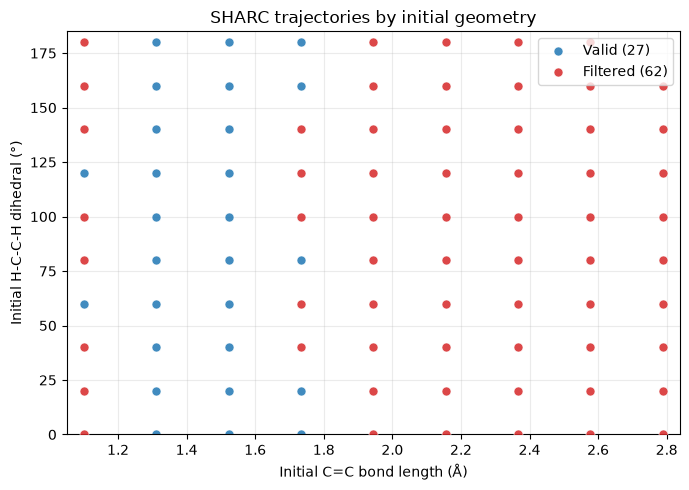

In [204]:
# Initial-condition grid: red denotes a trajectory with at least one sanity-filter failure.
plot_data = results.dropna(subset=["initial_cc_bond_angstrom", "initial_hcch_dihedral_deg"]).copy()
if plot_data.empty:
    raise ValueError("No trajectories contain both initial C--C and H-C-C-H coordinates to plot")

fig, ax = plt.subplots(figsize=(7, 5))
for status, color, label, zorder in (
    ("valid", "tab:blue", "Valid", 2),
    ("invalid_input", "0.65", "Invalid input", 1),
    ("filtered", "tab:red", "Filtered", 3),
):
    subset = plot_data[plot_data["status"] == status]
    if not subset.empty:
        ax.scatter(subset["initial_cc_bond_angstrom"], subset["initial_hcch_dihedral_deg"],
                   color=color, s=42, alpha=0.85, edgecolors="white", linewidths=0.5,
                   label=f"{label} ({len(subset)})", zorder=zorder)

INITIAL_CC_XLIM = (plot_data["initial_cc_bond_angstrom"].min() - 0.05, plot_data["initial_cc_bond_angstrom"].max() + 0.05)
INITIAL_HCCH_YLIM = (0, 185)
ax.set(xlabel="Initial C=C bond length (Å)", ylabel="Initial H-C-C-H dihedral (°)",
       xlim=INITIAL_CC_XLIM, ylim=INITIAL_HCCH_YLIM, title="SHARC trajectories by initial geometry")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


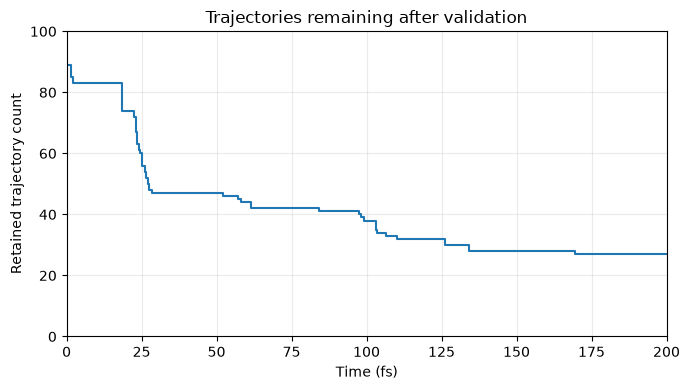

In [205]:
# Retained trajectories as a function of time (invalid-input trajectories excluded).
retained_end_times = []
for directory in discover_trajectories():
    retained = load_retained_trajectory(directory)
    if retained is not None:
        retained_end_times.append(retained[1][-1])
survival_time_fs = np.arange(0.0, TRAJECTORY_CUTOFF_TIME_FS + 1e-9, 0.5)
retained_counts = [sum(end_time >= time_fs for end_time in retained_end_times) for time_fs in survival_time_fs]
fig, ax = plt.subplots(figsize=(7, 4))
ax.step(survival_time_fs, retained_counts, where="post")
ax.set(xlabel="Time (fs)", ylabel="Retained trajectory count", ylim=(0, 100), xlim=(0, TRAJECTORY_CUTOFF_TIME_FS), title="Trajectories remaining after validation")
ax.grid(alpha=.25); fig.tight_layout(); plt.show()


## 4. Hop rate


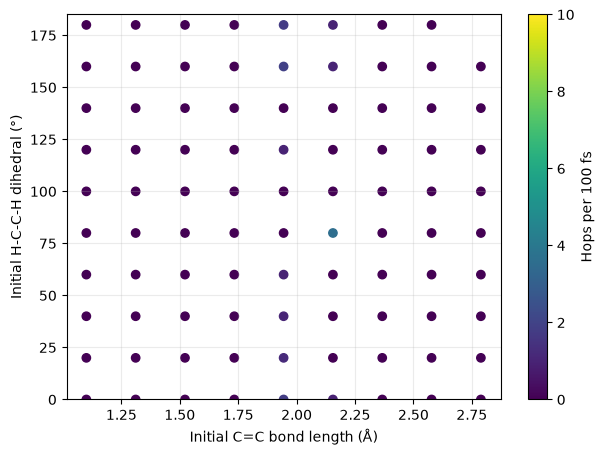

In [206]:
trajectory_dirs = discover_trajectories()
hop_rows=[]
for d in trajectory_dirs:
    try:
        retained = load_retained_trajectory(d)
        if retained is None: continue
        s,t,x,states,_,_,status=retained; cc,dih,_=initial_ethene_coordinates(s,x[0]); duration=t[-1]-t[0]
        if duration > 0: hop_rows.append((status,cc,dih,np.count_nonzero(states[1:]!=states[:-1])/duration*100))
    except (OSError,ValueError): pass
h=pd.DataFrame(hop_rows,columns=["status","cc","dih","rate"]).dropna()
fig,ax=plt.subplots(figsize=(7,5)); p=ax.scatter(h["cc"],h["dih"],c=h["rate"],cmap="viridis",vmin=0,vmax=10); fig.colorbar(p,ax=ax,label="Hops per 100 fs"); ax.set(xlabel="Initial C=C bond length (Å)",ylabel="Initial H-C-C-H dihedral (°)",ylim=(0,185));ax.grid(alpha=.25);plt.show()


## 5. Hop geometries

Every readable trajectory contributes each geometry at which its MCH state changes.


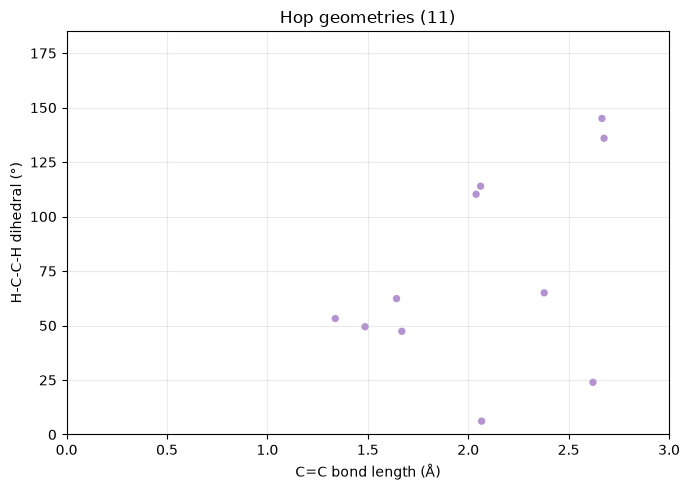

In [207]:
hop_cc, hop_dihedral = [], []
for directory in discover_trajectories():
    try:
        retained = load_retained_trajectory(directory)
        if retained is None: continue
        _, _, xyz, states, _, _, _ = retained
        hop_indices = np.flatnonzero(states[1:] != states[:-1]) + 1
        hop_cc.extend(np.linalg.norm(xyz[hop_indices, 0] - xyz[hop_indices, 1], axis=1))
        hop_dihedral.extend(abs(signed_dihedral_deg(xyz[index])) for index in hop_indices)
    except (OSError, ValueError):
        pass
if not hop_cc:
    raise ValueError("No hop geometries found")
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(hop_cc, hop_dihedral, s=28, alpha=.7, color="tab:purple", edgecolors="none")
ax.set(xlabel="C=C bond length (Å)", ylabel="H-C-C-H dihedral (°)", ylim=(0, 185), xlim=(0, 3), title=f"Hop geometries ({len(hop_cc)})")
ax.grid(alpha=.25); fig.tight_layout(); plt.show()


## 6. Quantum yield

,time_fs,quantum_yield,n_ground_state
0,0.0,NaN,0
1,1.0,NaN,0
2,2.0,NaN,0
3,3.0,NaN,0
4,4.0,NaN,0
...,...,...,...
196,196.0,NaN,0
197,197.0,NaN,0
198,198.0,NaN,0
199,199.0,NaN,0


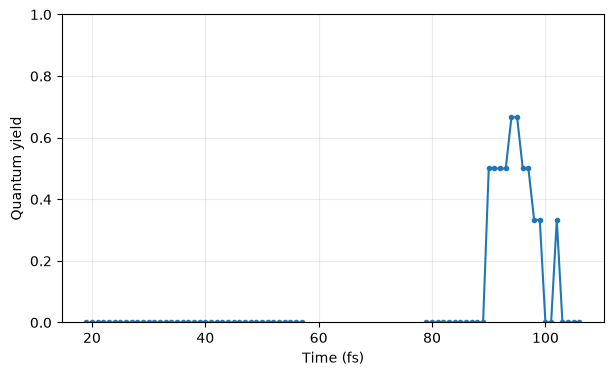

In [208]:
series=[]
for d in discover_trajectories():
    try:
        retained = load_retained_trajectory(d)
        if retained is None: continue
        s,t,x,states,_,_,_=retained; cc=np.linalg.norm(x[:,0]-x[:,1],axis=1)
        if cc.min()<.9 or cc.max()>3: continue
        initial=abs(signed_dihedral_deg(x[0]))<=90; switched=np.array([(abs(signed_dihedral_deg(f))<=90)!=initial for f in x]);series.append((t,states,switched))
    except (OSError,ValueError): pass
rows=[]
for now in np.arange(0,max(t[-1] for t,_,_ in series)+1e-9,1):
    values=[sw[int(np.argmin(abs(t-now)))] for t,st,sw in series if now<=t[-1] and st[int(np.argmin(abs(t-now)))]==1];rows.append((now,np.mean(values) if values else np.nan,len(values)))
qy=pd.DataFrame(rows,columns=["time_fs","quantum_yield","n_ground_state"]);display(qy)
fig,ax=plt.subplots(figsize=(7,4));ax.plot(qy.time_fs,qy.quantum_yield,marker="o",ms=3);ax.set(xlabel="Time (fs)",ylabel="Quantum yield",ylim=(0,1));ax.grid(alpha=.25);plt.show()


## 7. State population against time

Fractions use only sanity-valid trajectories available at each time point. MCH states 1, 2, and 3 correspond to S0, S1, and S2.


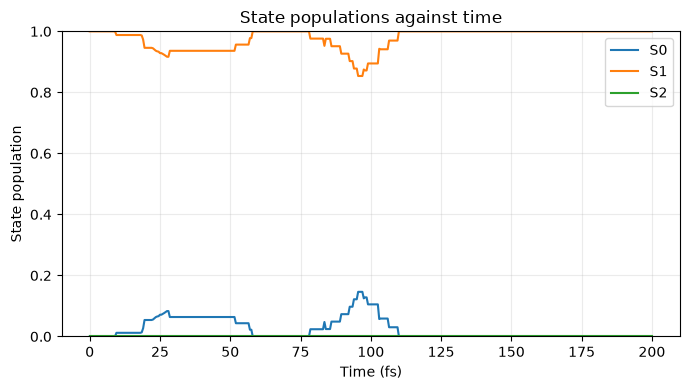

,time_fs,n_trajectories,S0,S1,S2
0,0.0,89,0.0,1.0,0.0
1,0.5,89,0.0,1.0,0.0
2,1.0,89,0.0,1.0,0.0
3,1.5,85,0.0,1.0,0.0
4,2.0,83,0.0,1.0,0.0
...,...,...,...,...,...
396,198.0,27,0.0,1.0,0.0
397,198.5,27,0.0,1.0,0.0
398,199.0,27,0.0,1.0,0.0
399,199.5,27,0.0,1.0,0.0


In [209]:
valid_state_series = []
for directory in discover_trajectories():
    try:
        retained = load_retained_trajectory(directory)
        if retained is None: continue
        _, time_fs, _, mch_state, _, _, _ = retained
        valid_state_series.append((time_fs, mch_state))
    except (OSError, ValueError):
        pass
if not valid_state_series:
    raise ValueError("No sanity-valid trajectories with readable state data")

population_rows = []
population_times = np.unique(np.concatenate([time_fs for time_fs, _ in valid_state_series]))
for time_fs in population_times:
    states_at_time = [states[np.flatnonzero(np.isclose(times, time_fs, rtol=0, atol=TIME_ATOL_FS))[0]]
                      for times, states in valid_state_series if np.any(np.isclose(times, time_fs, rtol=0, atol=TIME_ATOL_FS))]
    population_rows.append((time_fs, len(states_at_time), *[np.mean(np.asarray(states_at_time) == state) for state in (1, 2, 3)]))
state_population = pd.DataFrame(population_rows, columns=["time_fs", "n_trajectories", "S0", "S1", "S2"])
assert np.allclose(state_population[["S0", "S1", "S2"]].sum(axis=1), 1.0)
fig, ax = plt.subplots(figsize=(7, 4))
for state, color in zip(("S0", "S1", "S2"), ("tab:blue", "tab:orange", "tab:green")):
    ax.plot(state_population["time_fs"], state_population[state], label=state, color=color)
ax.set(xlabel="Time (fs)", ylabel="State population", ylim=(0, 1), title="State populations against time")
ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); plt.show()
display(state_population)


## 8. Excited-state lifetimes

For each valid trajectory and excited state, lifetime is the first continuous residence after first entering that state.


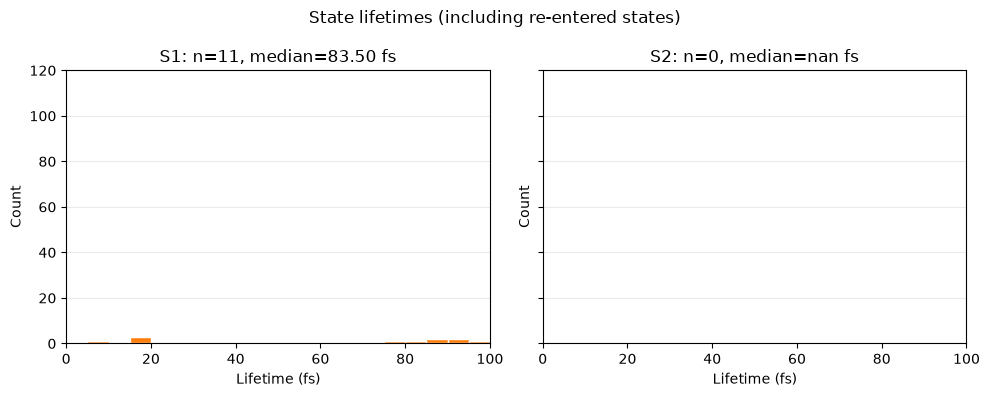

,trajectory,state,entry_time_fs,departure_time_fs,lifetime_fs
0,TRAJ_00041,S1,0.0,19.0,19.0
1,TRAJ_00042,S1,0.0,78.5,78.5
2,TRAJ_00043,S1,0.0,83.5,83.5
3,TRAJ_00044,S1,0.0,95.5,95.5
4,TRAJ_00047,S1,0.0,94.0,94.0
5,TRAJ_00049,S1,0.0,19.5,19.5
6,TRAJ_00050,S1,0.0,19.5,19.5
7,TRAJ_00051,S1,0.0,92.5,92.5
8,TRAJ_00055,S1,0.0,9.5,9.5
9,TRAJ_00059,S1,0.0,86.0,86.0


In [210]:
def completed_state_residences(time_fs, states, target_state):
    """Return completed contiguous state residences; exclude cutoff-censored intervals."""
    starts = np.flatnonzero((states == target_state) & np.r_[True, states[1:] != states[:-1]])
    intervals = []
    for start in starts:
        departures = np.flatnonzero(states[start + 1:] != target_state)
        if not len(departures):
            continue
        departure = int(start + 1 + departures[0])
        intervals.append((float(time_fs[start]), float(time_fs[departure]), float(time_fs[departure] - time_fs[start])))
    return intervals

_test_time = np.arange(5, dtype=float)
assert completed_state_residences(_test_time, np.array([2, 1, 2, 1, 1]), 2) == [(0.0, 1.0, 1.0), (2.0, 3.0, 1.0)]
assert completed_state_residences(_test_time, np.array([1, 3, 3, 3, 3]), 3) == []

lifetime_rows = []
for directory in discover_trajectories():
    try:
        retained = load_retained_trajectory(directory)
        if retained is None: continue
        _, time_fs, _, states, _, _, _ = retained
        for state_number, state_label in ((2, "S1"), (3, "S2")):
            for entry_time_fs, departure_time_fs, lifetime_fs in completed_state_residences(time_fs, states, state_number):
                lifetime_rows.append({"trajectory": directory.name, "state": state_label, "entry_time_fs": entry_time_fs, "departure_time_fs": departure_time_fs, "lifetime_fs": lifetime_fs})
    except (OSError, ValueError):
        pass
excited_state_lifetimes = pd.DataFrame(lifetime_rows)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for axis, state in zip(axes, ("S1", "S2")):
    values = excited_state_lifetimes.loc[excited_state_lifetimes["state"] == state, "lifetime_fs"]
    axis.hist(values, bins=range(0,101,5), color="tab:orange" if state == "S1" else "tab:green", edgecolor="white")
    median = values.median() if len(values) else np.nan
    axis.set(ylim=(0, 120), xlim=(0,100), xlabel="Lifetime (fs)", ylabel="Count", title=f"{state}: n={len(values)}, median={median:.2f} fs")
    axis.grid(axis="y", alpha=.25)
fig.suptitle("State lifetimes (including re-entered states)"); fig.tight_layout(); plt.show()
display(excited_state_lifetimes)
